<a href="https://colab.research.google.com/github/robertrichard86/Python/blob/main/Regress%C3%A3o_Linear_M%C3%BAltipla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise do Impacto das Variáveis sobre a Produção

**Objetivo:** Este estudo tem como finalidade analisar o impacto de diferentes variáveis operacionais (máquinas, trabalhadores, horas trabalhadas e feriados) sobre a `Quantidade Produzida`.

Para isso, aplicaremos um modelo de **Regressão Linear Múltipla**, técnica estatística que permite prever e entender o comportamento de uma variável dependente ($Y$) com base em múltiplas variáveis independentes ($X$)[cite: 1].

A análise focará na significância estatística de cada preditor, no ajuste do modelo (através do $R^2$ Ajustado) e na validação das premissas de Gauss-Markov para garantir a confiabilidade dos resultados[cite: 1].

In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('Exercicio_Producao.csv')

df.columns = df.columns.str.strip()

display(df.head())

,Data,Quantidade Produzida,Quantidade de Maquinas,Quantidade de Trabalhadores,Horas Trabalhadas,Feriado
0,01/01/2023,6285,11,12,6,1
1,02/01/2023,9482,8,23,11,0
2,03/01/2023,10548,15,22,10,0
3,04/01/2023,10990,12,27,11,0
4,05/01/2023,8763,9,26,7,0


## 1. Estruturação do Modelo OLS (Mínimos Quadrados Ordinários)

Nesta etapa, separamos nossas variáveis:
*   **Variável Dependente ($Y$):** `Quantidade Produzida`.
*   **Variáveis Independentes ($X$):** `Quantidade de Maquinas`, `Quantidade de Trabalhadores`, `Horas Trabalhadas` e `Feriado`.

A coluna `Data` será descartada do modelo matemático por ser apenas um identificador temporal. Em seguida, adicionaremos a constante ($\beta_0$, ou intercepto) exigida pela equação matemática da regressão linear[cite: 1].

In [2]:
# 2. Definindo variáveis preditoras (X) e alvo (y)
y = df['Quantidade Produzida']
X = df[['Quantidade de Maquinas', 'Quantidade de Trabalhadores', 'Horas Trabalhadas', 'Feriado']]

# 3. Adicionando a constante (o Beta 0 / Intercepto)
X = sm.add_constant(X)

# 4. Treinando o modelo
modelo = sm.OLS(y, X).fit()

# 5. Exibindo o relatório estatístico completo
print(modelo.summary())

                             OLS Regression Results                             
Dep. Variable:     Quantidade Produzida   R-squared:                       0.962
Model:                              OLS   Adj. R-squared:                  0.961
Method:                   Least Squares   F-statistic:                     2254.
Date:                  Mon, 04 May 2026   Prob (F-statistic):          2.52e-253
Time:                          01:21:27   Log-Likelihood:                -2560.9
No. Observations:                   365   AIC:                             5132.
Df Residuals:                       360   BIC:                             5151.
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

## 2. Validação das Premissas de Gauss-Markov

Para que os resultados da regressão sejam confiáveis e os p-valores válidos, é obrigatório verificar se o modelo atende às premissas fundamentais[cite: 1]:

1.  **Ausência de Multicolinearidade:** Verificada através do *Variance Inflation Factor* (VIF). Valores de VIF > 5 indicam correlação problemática entre as variáveis independentes[cite: 1].
2.  **Independência dos Erros:** Verificada no relatório acima pelo teste de **Durbin-Watson**. Valores próximos a 2 indicam ausência de autocorrelação nos resíduos[cite: 1].
3.  **Normalidade dos Resíduos:** Aplicaremos o teste de **Shapiro-Wilk**. Se o valor de $p > 0,05$, os dados são normais[cite: 1].
4.  **Homocedasticidade e Linearidade:** Avaliadas visualmente através do gráfico de dispersão dos resíduos. Buscamos um padrão aleatório, sem formar figuras como "funis" ou "curvas"[cite: 1].

--- 1. Teste de Multicolinearidade (VIF) ---


,Variável,VIF
1,Quantidade de Maquinas,1.022749
2,Quantidade de Trabalhadores,1.076584
3,Horas Trabalhadas,1.024396
4,Feriado,1.075005



--- 2. Teste de Normalidade de Shapiro-Wilk ---
Estatística: 0.8398, P-valor: 0.0000
Conclusão: Os resíduos NÃO seguem uma distribuição normal (Rejeita H0).


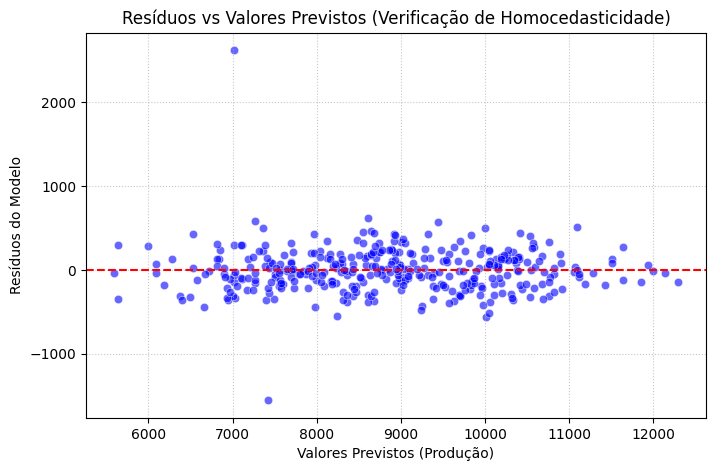

In [3]:
print("--- 1. Teste de Multicolinearidade (VIF) ---")
vif_data = pd.DataFrame()
vif_data["Variável"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# Exibimos a partir do índice 1 para ignorar o VIF da constante
display(vif_data[1:])

print("\n--- 2. Teste de Normalidade de Shapiro-Wilk ---")
residuos = modelo.resid
stat, p_valor = stats.shapiro(residuos)
print(f"Estatística: {stat:.4f}, P-valor: {p_valor:.4f}")

if p_valor > 0.05:
    print("Conclusão: Os resíduos seguem uma distribuição normal (Falha em rejeitar H0).")
else:
    print("Conclusão: Os resíduos NÃO seguem uma distribuição normal (Rejeita H0).")

# 3. Gráfico de Resíduos (Homocedasticidade)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=modelo.fittedvalues, y=residuos, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs Valores Previstos (Verificação de Homocedasticidade)')
plt.xlabel('Valores Previstos (Produção)')
plt.ylabel('Resíduos do Modelo')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 3. Análise do Modelo e Principais Descobertas

**1. Ajuste do Modelo ($R^2$ Ajustado):**
*   O modelo apresentou um $R^2$ Ajustado de **0,961**. Isso significa que **96,1% da variação na Quantidade Produzida** é explicada pelas variáveis selecionadas (Máquinas, Trabalhadores, Horas e Feriados). Trata-se de um ajuste excelente, provando que o modelo tem um altíssimo poder explicativo sobre a produção da empresa.

**2. Significância das Variáveis (P-Value):**
*   Observando a coluna `P>|t|`, nota-se que todas as variáveis preditoras (`Quantidade de Maquinas`, `Quantidade de Trabalhadores`, `Horas Trabalhadas` e `Feriado`) registraram um valor de **0.000**. Como todos os p-valores são estritamente menores que a margem de 0,05, concluímos que **todas essas variáveis são estatisticamente significantes**. Nenhuma delas está no modelo por acaso; todas impactam ativamente o volume de produção. *(Nota: O intercepto/constante obteve 0.509, mas para a nossa análise prática, o foco recai sobre as variáveis operacionais).*

**3. Interpretação dos Coeficientes ($\beta$):**
Analisando a coluna `coef`, podemos quantificar o impacto exato de cada fator na linha de produção (sempre assumindo que as demais variáveis permanecem constantes):
*   **Horas Trabalhadas (358.24):** É o fator positivo de maior peso absoluto. Cada 1 hora adicional de trabalho resulta em um aumento médio de aproximadamente **358 unidades** produzidas.
*   **Quantidade de Máquinas (243.76):** A adição de apenas 1 máquina na operação gera um acréscimo médio de cerca de **244 unidades** na produção.
*   **Quantidade de Trabalhadores (147.19):** A contratação ou alocação de 1 trabalhador extra aumenta a produção média em **147 unidades**.
*   **Feriado (-664.53):** Sendo a única variável de impacto negativo (coeficiente com sinal de menos), a ocorrência de um feriado impacta severamente a operação, reduzindo a produção média em **665 unidades** na comparação com dias de trabalho convencionais.

**Conclusão das Premissas:**
*   **Independência dos Erros:** A estatística de **Durbin-Watson** resultou em **2.001**. Este é o cenário ideal apontado na literatura (muito próximo de 2)[cite: 1], confirmando a total ausência de autocorrelação nos resíduos. O erro de um dia de produção não está correlacionado ao do dia seguinte.
*   **Ausência de Multicolinearidade:** O teste confirmou a saúde do modelo. Os fatores de inflação da variância (VIF) ficaram entre **1.02 e 1.07** para todas as variáveis. Como todos os valores estão muito abaixo do limite crítico de 5[cite: 1], garantimos que as variáveis preditoras são independentes entre si e não confundem o modelo.
*   **Normalidade dos Resíduos:** O teste de **Shapiro-Wilk** retornou um P-valor de **0.0000**, o que nos leva a rejeitar a hipótese nula, indicando que os resíduos NÃO seguem uma distribuição normal estrita[cite: 1]. No contexto de uma linha de produção, isso ocorre devido à presença de *outliers* naturais (dias atípicos de altíssima ou baixíssima performance não explicados pelas variáveis base). Contudo, devido ao tamanho considerável da amostra ($N = 365$ observações) e aos altos níveis de significância ($P<0,001$) e ajuste global ($R^2$ de 0,961)[cite: 1], o modelo mantém sua robustez e capacidade analítica para tomada de decisão.